## Libraries

In [ ]:
#Made by Carlos jose yepes aristizabal :D

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv('data/src/OnlineRetail.csv',encoding='latin-1',sep=',')
print(f"Rows and cols: {df.shape}\n")
print(f"\nData types: {df.dtypes}")

print(f"\nNulls in CustomerID: {df['CustomerID'].isna().sum()}")
print(f"\nPrices below 0: {(df['Quantity']<=0).sum()}")

df.head(5)

Rows and cols: (541909, 8)


Data types: InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Nulls in CustomerID: 135080

Prices below 0: 10624


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [29]:
#Check what happened with data below 0
quantity_below_zero = df[df['Quantity']<=0]
quantity_below_zero

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


## Data cleaning

In [30]:
#1. Delete null values and filter data
df = df.dropna(subset='CustomerID')
df = df[df['Quantity']>=0]
df = df[df['UnitPrice']>0]

print(f"\nNulls in CustomerID: {df['CustomerID'].isna().sum()}")
print(f"Rows and cols after drop nulls and invalids: {df.shape}\n")

#2. Data transformation
df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
#Creation of necessary columns
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

#3. Confirmation
print(f"\nData types: {df.dtypes}")

df


Nulls in CustomerID: 0
Rows and cols after drop nulls and invalids: (397884, 8)


Data types: InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
TotalPrice            float64
dtype: object


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


## RFM

In [31]:
max_date_reference = df['InvoiceDate'].max() + pd.Timedelta(days=1)
max_date_reference

Timestamp('2011-12-10 12:50:00')

In [32]:
df_rfm = (df.groupby('CustomerID')
            .agg({
                'TotalPrice': 'sum',
                'InvoiceNo': 'nunique',
                'InvoiceDate': 'max'
            })
            .rename(columns={
                'TotalPrice': 'Monetary',
                'InvoiceNo': 'Frequency',
                'InvoiceDate': 'Recency'
            })
            .assign(Recency=lambda x: (max_date_reference - x['Recency']).dt.days)
          )
df_rfm

,Monetary,Frequency,Recency
CustomerID,,,
12346,77183.60,1,326
12347,4310.00,7,2
12348,1797.24,4,75
12349,1757.55,1,19
12350,334.40,1,310
...,...,...,...
18280,180.60,1,278
18281,80.82,1,181
18282,178.05,2,8


## Data scaling

In [33]:
scaler = StandardScaler()
#Scale RFM
x_scaled = scaler.fit_transform(df_rfm[['Monetary','Frequency','Recency']])

print(x_scaled[:5])

[[ 8.35866818 -0.4250965   2.33457414]
 [ 0.25096626  0.3544168  -0.90534032]
 [-0.02859601 -0.03533985 -0.17535959]
 [-0.0330118  -0.4250965  -0.73534481]
 [-0.19134727 -0.4250965   2.17457836]]


## Elbow method

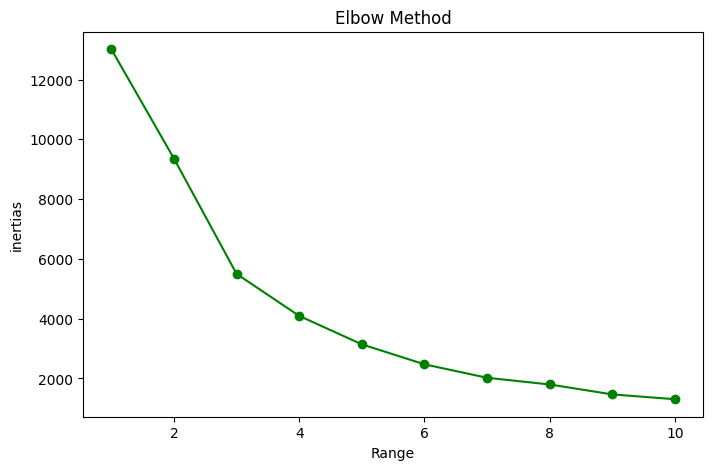

In [34]:
inertias = []

for k in range(1,11):
    km = KMeans(n_clusters=k,random_state=42)
    km.fit(x_scaled)
    inertias.append(km.inertia_)

#  graphic elbow
plt.figure(figsize=(8,5))
plt.plot(range(1,11),inertias, 'go-')
plt.xlabel('Range')
plt.ylabel('inertias')
plt.title('Elbow Method')
plt.show()

## Silhouette score


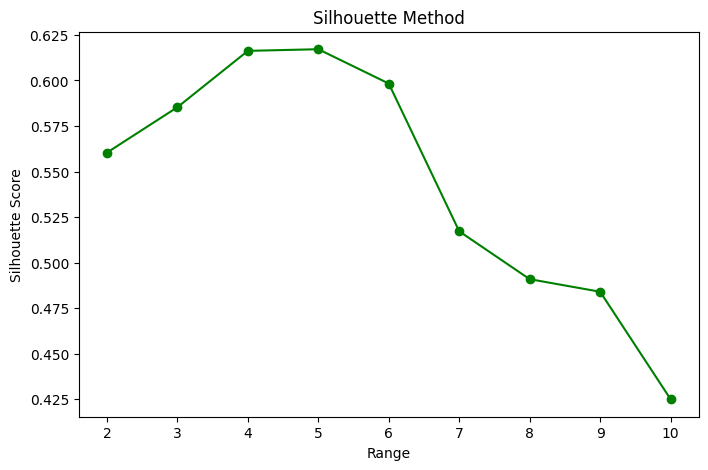

In [35]:
silhouette_scores = []

for k in range(2,11):
    km = KMeans(n_clusters = k, random_state = 42)
    labels = km.fit_predict(x_scaled)
    score = silhouette_score(x_scaled,labels)
    silhouette_scores.append(score)

#  graphic silhouette
plt.figure(figsize=(8,5))
plt.plot(range(2,11),silhouette_scores, 'go-')
plt.xlabel('Range')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.show()



Elbow method suggest 4 clusters, and Shilhouette method suggest 4-5 clusters. We'll work with 4 K

## Training model

In [36]:
km_final = KMeans(n_clusters=4,random_state=42)
km_final.fit(x_scaled)

#Add the # of K in df
df_rfm['Clusters'] = km_final.labels_
df_rfm.head(5)


,Monetary,Frequency,Recency,Clusters
CustomerID,,,,
12346,77183.60,1,326,3
12347,4310.00,7,2,0
12348,1797.24,4,75,0
12349,1757.55,1,19,0
12350,334.40,1,310,1


| Cluster | Nombre    | Estrategia de marketing                                      |
|----------|------------|---------------------------------------------------------------|
| 0        | Moderados | Campaña de reactivación — descuentos, recordatorios          |
| 1        | Inactivos | Win-back agresivo o descartarlos del presupuesto             |
| 2        | VIP       | Fidelización — programa de lealtad, acceso exclusivo         |
| 3        | Líquidos  | Upselling — empujarlos hacia VIP                             |

## Principal Component Analysis

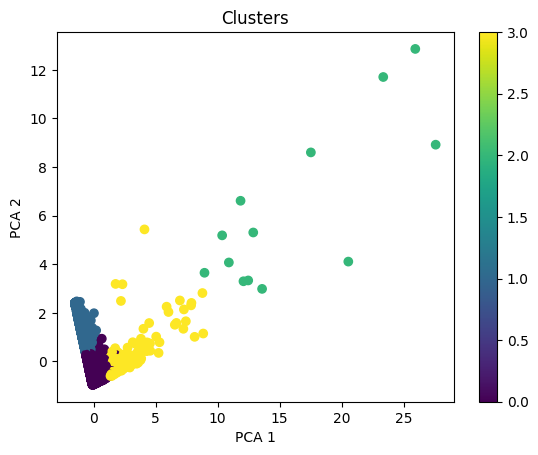

In [37]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)


""" plt.figure(figsize=(8,5))
plt.plot(range(2,11),silhouette_scores, 'go-')
plt.xlabel('Range')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.show() """


plt.scatter(X_pca[:,0], X_pca[:,1], c=df_rfm['Clusters'], cmap='viridis')
plt.colorbar()
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters')

plt.show()


In [38]:
# Assign a clear name

def assign_name(x):
    if x == 0:
        return "Moderados"
    elif x == 1:
        return "Moderated"
    elif x ==2 :
        return "VIP"
    elif x ==3:
        return "Liquids"

df_rfm["clusters_name"]=df_rfm["Clusters"].apply(assign_name)
print(f"Distribution clusters customers: {df_rfm.clusters_name.value_counts()}")

Distribution clusters customers: clusters_name
Moderados    3054
Moderated    1067
Liquids       204
VIP            13
Name: count, dtype: int64


## Export data

In [41]:
#Extract the data processed

df_rfm.to_parquet('data/out/data_processed_w_clusters.parquet',index=False)
print('Saved data succesfully! :D')

Saved data succesfully! :D
